# 01 · Boltz-2 co-folding QC

Quality control of our Pass-1 co-folding run for target 588689 (Dengue NS5). Each compound was co-folded once; here we look at the model-confidence outputs (pLDDT, pTM, ipTM, ligand ipTM, PDE) to check the predicted complexes are sane before they feed the affinity stage.

> Preliminary. These use the ~20k compounds co-folded so far (a partial, roughly CID-ordered — hence roughly random — sample of the 49,985-compound library). Absolute numbers will shift as folding completes, and none of this includes fine-tuning yet, so nothing here speaks to the paper head-FT claim. What it does show: whether the co-folding is healthy, and whether the structural-confidence signals carry any activity information.

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
QC = pd.read_csv(ROOT / "results/runs/588689/qc.csv")
# all text black, normal weight (no bold)
BLK="#000000"; GRID="#dedede"
PALETTE=["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#4a3aa7","#e34948","#008300"]
ACTIVE="#1baf7a"; INACTIVE="#9aa0a6"; BLUE="#2a78d6"
mpl.rcParams.update({
  "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.6,"axes.axisbelow":True,
  "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":100})
METRICS=["confidence","complex_plddt","ptm","iptm","ligand_iptm","complex_pde"]
print(f"folded compounds: {len(QC)}   actives: {int(QC.Active.sum())} ({QC.Active.mean()*100:.2f}%)")


folded compounds: 21061   actives: 238 (1.13%)


## Coverage and representativeness
How much of the library is folded, and is the folded subset representative of the full active rate?

In [2]:
full_rate = 0.972  # full-library active rate for 588689 (486/49985 * 100)
print(f"folded: {len(QC)} / 49985 ({len(QC)/49985*100:.1f}%)")
print(f"folded active rate: {QC.Active.mean()*100:.2f}%   full-library: {full_rate:.2f}%")
print("-> folded subset tracks the full active rate, so preliminary stats are representative"
      if abs(QC.Active.mean()*100-full_rate)<0.3 else "-> some sampling skew, read with care")

folded: 21061 / 49985 (42.1%)
folded active rate: 1.13%   full-library: 0.97%
-> folded subset tracks the full active rate, so preliminary stats are representative


## Confidence metric distributions
Distribution of each Boltz-2 confidence output across the folded complexes.

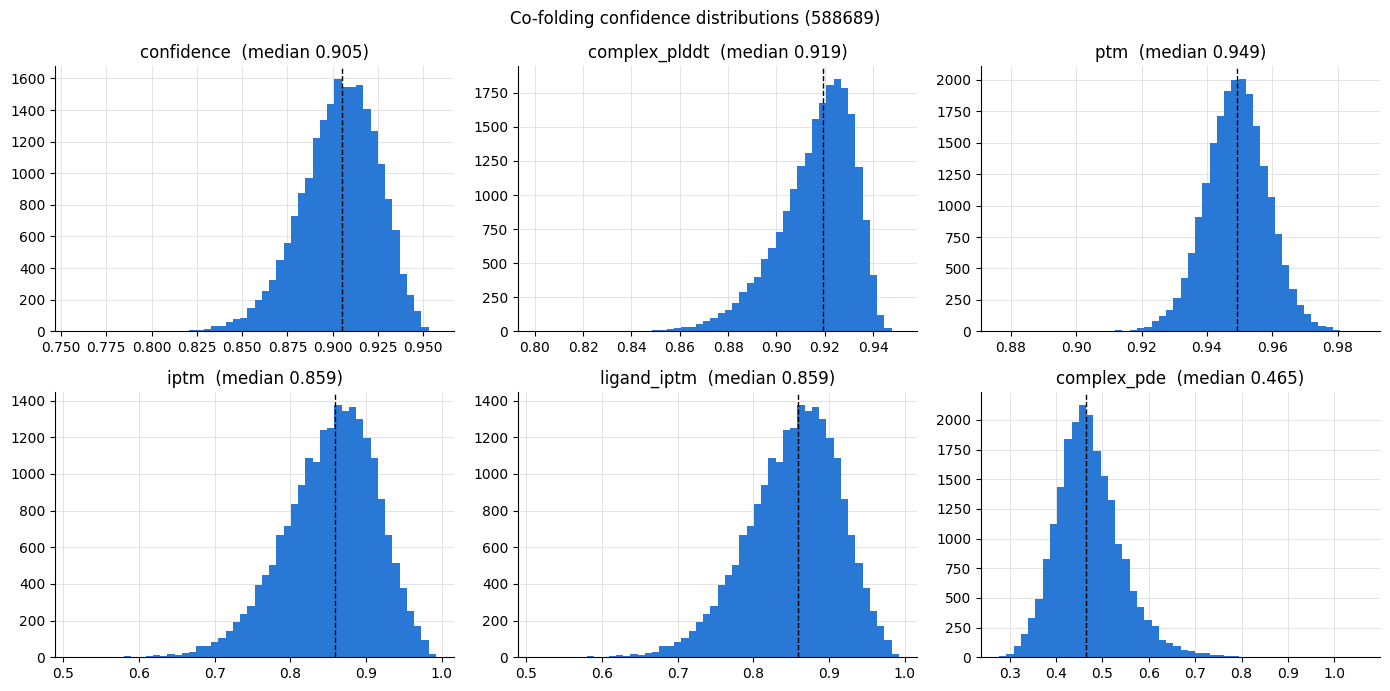

In [3]:
fig,axes=plt.subplots(2,3,figsize=(14,7))
for ax,m in zip(axes.ravel(),METRICS):
    x=QC[m].dropna()
    ax.hist(x,bins=50,color=BLUE)
    ax.axvline(x.median(),color=BLK,ls="--",lw=1)
    ax.set_title(f"{m}  (median {x.median():.3f})")
fig.suptitle("Co-folding confidence distributions (588689)")
plt.tight_layout(); plt.show()

## Fraction of complexes above common confidence thresholds

In [4]:
checks=[("complex_plddt",0.7),("complex_plddt",0.8),("ligand_iptm",0.5),("ligand_iptm",0.7),("confidence",0.8)]
rows=[dict(metric=m,threshold=t,frac_above=round((QC[m]>=t).mean(),3)) for m,t in checks]
pd.DataFrame(rows)

,metric,threshold,frac_above
0,complex_plddt,0.7,1.000
1,complex_plddt,0.8,1.000
2,ligand_iptm,0.5,1.000
3,ligand_iptm,0.7,0.986
4,confidence,0.8,1.000


## Do pLDDT and ligand-placement confidence agree?
Protein-fold confidence (complex pLDDT) vs ligand-pose confidence (ligand ipTM). A high-pLDDT / low-ipTM cluster = confident fold but uncertain ligand placement.

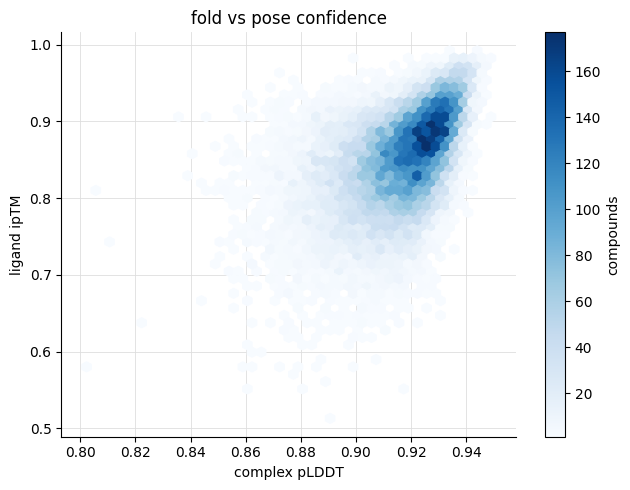

In [5]:
fig,ax=plt.subplots(figsize=(6.5,5))
hb=ax.hexbin(QC.complex_plddt,QC.ligand_iptm,gridsize=45,cmap="Blues",mincnt=1)
ax.set_xlabel("complex pLDDT"); ax.set_ylabel("ligand ipTM"); ax.set_title("fold vs pose confidence")
plt.colorbar(hb,label="compounds"); plt.tight_layout(); plt.show()